#機械学習の勉強

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



In [3]:
df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\Boston.csv')
display(df.head(3))

,CRIME,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
0,high,0.0,18.10,0,0.718,3.561,87.9,1.6132,24.0,666,20.2,7.12,27.5
1,low,0.0,8.14,0,0.538,5.950,82.0,3.9900,4.0,307,21.0,27.71,13.2
2,very_low,82.5,2.03,0,0.415,6.162,38.4,6.2700,2.0,348,14.7,7.43,24.1


In [4]:
df['CRIME'].value_counts()

CRIME
very_low    50
high        25
low         25
Name: count, dtype: int64

In [5]:
crime=pd.get_dummies(df['CRIME'],drop_first=True,dtype=int)
df2=pd.concat([df,crime],axis=1)
df2=df2.drop(['CRIME'],axis=1)
df2.head(2)

,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE,low,very_low
0,0.0,18.10,0,0.718,3.561,87.9,1.6132,24.0,666,20.2,7.12,27.5,0,0
1,0.0,8.14,0,0.538,5.950,82.0,3.9900,4.0,307,21.0,27.71,13.2,1,0


In [6]:
train_val,test=train_test_split(df2,test_size=0.2,random_state=0)

In [7]:
train_val.isnull().sum()

ZN          0
INDUS       0
CHAS        0
NOX         1
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
LSTAT       0
PRICE       0
low         0
very_low    0
dtype: int64

In [8]:
train_val_mean=train_val.mean()
train_val2=train_val.fillna(train_val_mean)

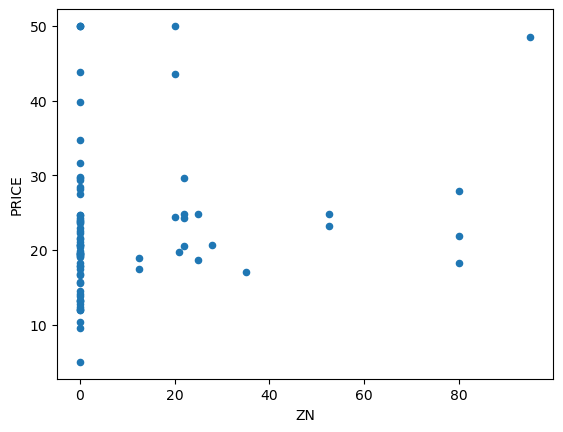

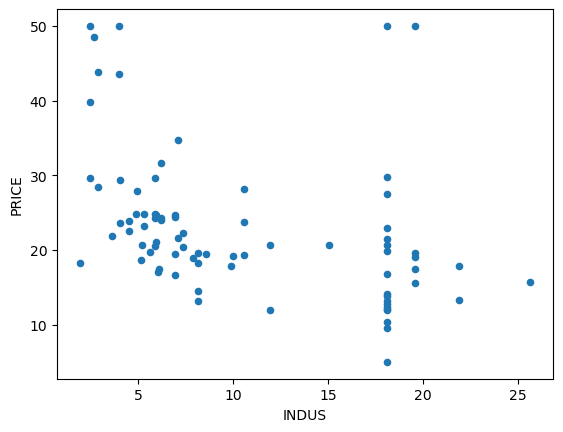

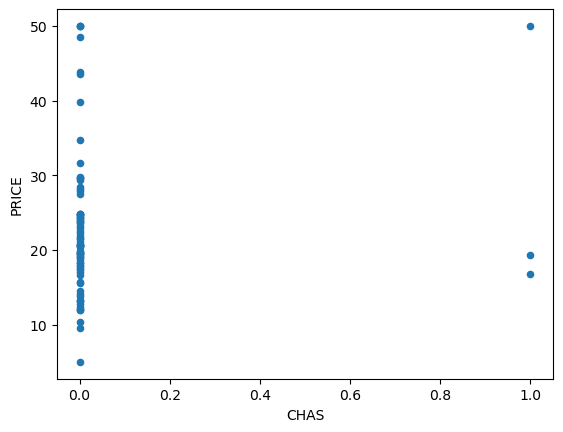

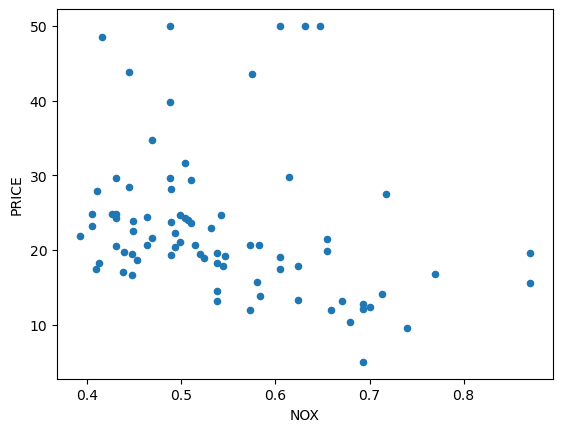

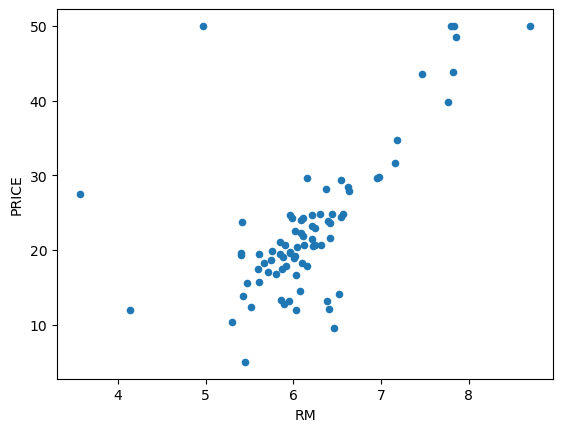

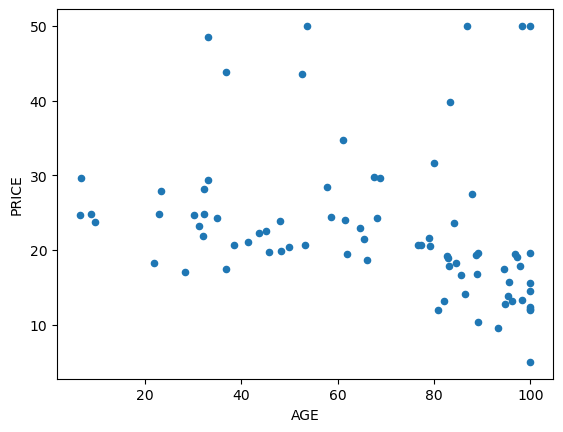

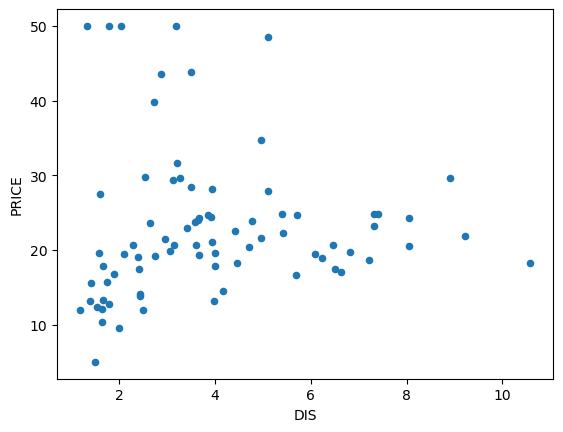

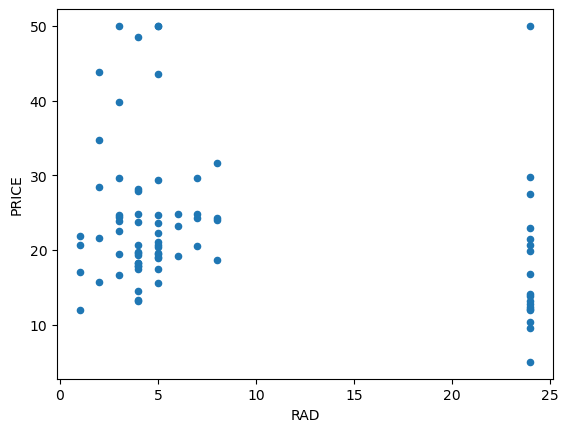

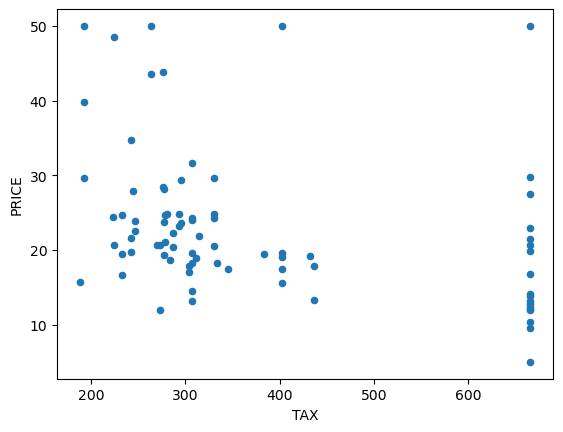

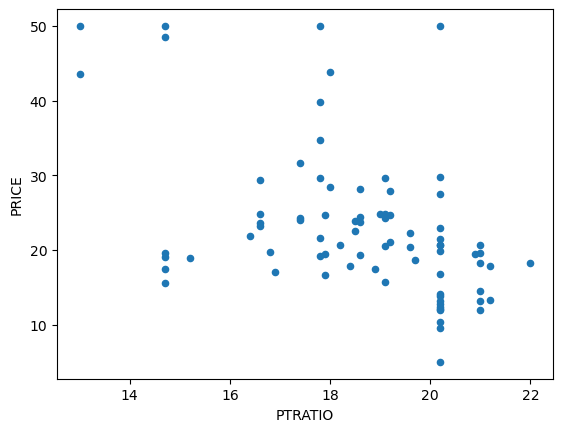

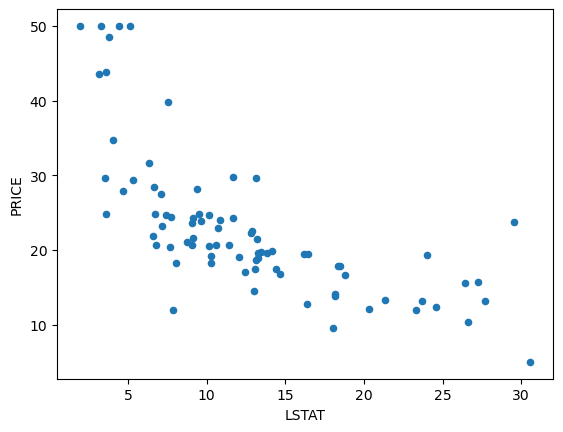

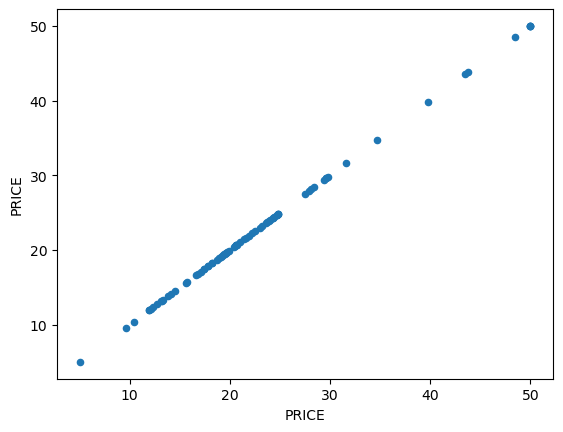

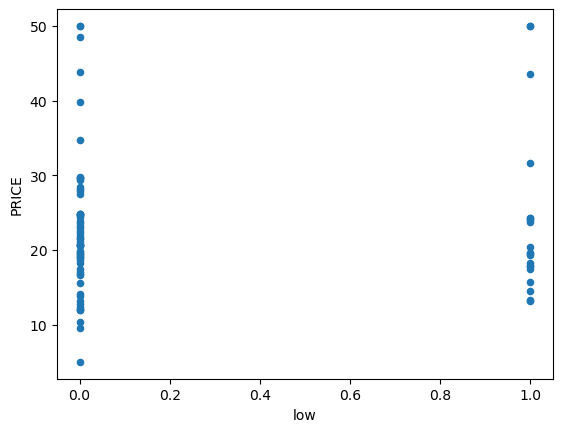

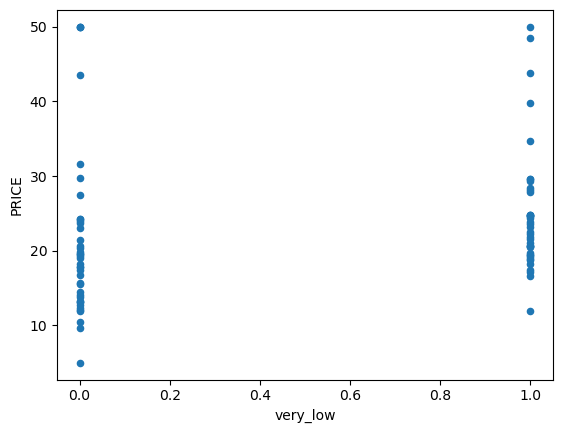

In [9]:
colname=train_val2.columns
for name in colname:
    train_val2.plot(kind='scatter',x=name,y='PRICE')

In [10]:
#8-9
#RMの外れ値
out_line1=train_val2[(train_val2['RM']<6)&
                    (train_val2['PRICE']>40)].index

#PTRATIOの外れ値
out_line2=train_val2[(train_val2['PTRATIO']>18)&
                    (train_val2['PRICE']>40)].index

print(out_line1,out_line2)

Index([76], dtype='int64') Index([76], dtype='int64')


In [11]:
train_val3=train_val2.drop([76],axis=0)

In [12]:
col=['INDUS','NOX','RM','PTRATIO','LSTAT','PRICE']

train_val4=train_val3[col]
train_val4.head(3)

,INDUS,NOX,RM,PTRATIO,LSTAT,PRICE
43,5.86,0.431,6.108,19.1,9.16,24.3
62,5.86,0.431,6.957,19.1,3.53,29.6
3,21.89,0.624,6.151,21.2,18.46,17.8


In [13]:
train_val4.corr()

,INDUS,NOX,RM,PTRATIO,LSTAT,PRICE
INDUS,1.000000,0.785722,-0.403129,0.249438,0.578406,-0.470889
NOX,0.785722,1.000000,-0.272996,0.077533,0.484295,-0.325289
RM,-0.403129,-0.272996,1.000000,-0.404568,-0.560454,0.753771
PTRATIO,0.249438,0.077533,-0.404568,1.000000,0.326563,-0.542449
LSTAT,0.578406,0.484295,-0.560454,0.326563,1.000000,-0.693490
PRICE,-0.470889,-0.325289,0.753771,-0.542449,-0.693490,1.000000


In [14]:
train_cor=train_val4.corr()['PRICE']
display(train_cor)

INDUS     -0.470889
NOX       -0.325289
RM         0.753771
PTRATIO   -0.542449
LSTAT     -0.693490
PRICE      1.000000
Name: PRICE, dtype: float64

In [15]:
print(abs(1))
print(abs(-2))

1
2


In [16]:
se=pd.Series([1,-2,3,-4])
se.map(abs)

0    1
1    2
2    3
3    4
dtype: int64

In [17]:
se=pd.Series([1,-2,3,-4])
se.map({
    1:'chipi',
    3:'happy',
    -2:'dubi',
    -4:'pipipi'
})

0     chipi
1      dubi
2     happy
3    pipipi
dtype: object

In [18]:
abs_cor=train_cor.map(abs)
display(abs_cor)

INDUS      0.470889
NOX        0.325289
RM         0.753771
PTRATIO    0.542449
LSTAT      0.693490
PRICE      1.000000
Name: PRICE, dtype: float64

In [19]:
abs_cor.sort_values(ascending=False)

PRICE      1.000000
RM         0.753771
LSTAT      0.693490
PTRATIO    0.542449
INDUS      0.470889
NOX        0.325289
Name: PRICE, dtype: float64

In [20]:
col=['RM','LSTAT','PTRATIO']
x=train_val4[col]
t=train_val4[['PRICE']]

x_train,x_test,y_train,y_test=train_test_split(x,t,test_size=0.2,random_state=0)

In [21]:
from sklearn.preprocessing import StandardScaler


def learn(x,t):
    x_train,x_val,y_train,y_val=train_test_split(x,t,test_size=0.2,random_state=0)
    #訓練データの標準化
    sc_model_x=StandardScaler()
    sc_model_y=StandardScaler()
    sc_model_x.fit(x_train) 
    sc_x_train=sc_model_x.transform(x_train) 
    sc_model_y.fit(y_train) 
    sc_y_train=sc_model_y.transform(y_train) 

    #学習
    model=LinearRegression()
    model.fit(sc_x_train,sc_y_train)

    #検証データの標準化
    sc_x_val=sc_model_x.transform(x_val) 
    sc_y_val=sc_model_y.transform(y_val) 

    #訓練データと検証データの決定係数計算
    train_score=model.score(sc_x_train,sc_y_train)
    val_score=model.score(sc_x_val,sc_y_val)

    return train_score,val_score

In [22]:
x=train_val3.loc[:,['RM','LSTAT','PTRATIO']]
t=train_val3[['PRICE']]
s1,s2=learn(x,t)
print(s1,s2)

0.7175897572515981 0.7359028880290996


In [23]:
x=train_val3.loc[:,['RM','LSTAT','PTRATIO','INDUS']]
t=train_val3[['PRICE']]
s1,s2=learn(x,t)
print(s1,s2)

0.7190252930186809 0.7295535344941488


In [24]:
x['RM2']=x['RM']**2
x=x.drop('INDUS',axis=1)
x.head(2)

,RM,LSTAT,PTRATIO,RM2
43,6.108,9.16,19.1,37.307664
62,6.957,3.53,19.1,48.399849


In [25]:
x.loc[2000]=[10,7,8,100]
print(x.tail(2))

x=x.drop(2000,axis=0)

         RM  LSTAT  PTRATIO       RM2
44     5.85   8.77     19.2   34.2225
2000  10.00   7.00      8.0  100.0000


In [26]:
s1,s2=learn(x,t)
print(s1,s2)

0.8456207631185567 0.8372526287986781


In [27]:
#LSTAT列の二乗を追加
x['LSTAT2']=x['LSTAT']**2

x['PTRATIO2']=x['PTRATIO']**2
s1,s2=learn(x,t)
print(s1,s2)


0.864383498898444 0.8678022326740731


In [28]:
sel1=pd.Series([1,2,3])
sel2=pd.Series([10,20,30])
sel1+sel2

0    11
1    22
2    33
dtype: int64

In [29]:
x['RM*LSTAT']=x['RM']*x['LSTAT']
x.head(2)

,RM,LSTAT,PTRATIO,RM2,LSTAT2,PTRATIO2,RM*LSTAT
43,6.108,9.16,19.1,37.307664,83.9056,364.81,55.94928
62,6.957,3.53,19.1,48.399849,12.4609,364.81,24.55821


In [30]:
s1,s2=learn(x,t)
print(s1,s2)

0.8668534967796697 0.8739347357775972


In [31]:
#訓練データと検証データを合わせて再学習させるので、再度標準化する
sc_model_x2=StandardScaler()
sc_model_x2.fit(x) 
sc_x=sc_model_x2.transform(x) 

sc_model_y2=StandardScaler()
sc_model_y2.fit(t) 
sc_y=sc_model_y2.transform(t) 

model=LinearRegression()
model.fit(sc_x,sc_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
test2=test.fillna(train_val.mean())
x_test=test2.loc[:,['RM','LSTAT','PTRATIO']]
y_test=test2[['PRICE']]

x_test['RM2']=x_test['RM']**2
x_test['LSTAT2']=x_test['LSTAT']**2
x_test['PTRATIO2']=x_test['PTRATIO']**2

x_test['RM*LSTAT']=x_test['RM']*x_test['LSTAT']



sc_x_test=sc_model_x2.transform(x_test)
sc_y_test=sc_model_y2.transform(y_test)

In [33]:
model.score(sc_x_test,sc_y_test)

0.7649249353669054

In [34]:
import pickle

with open('boston.pkl','wb')as f:
    pickle.dump(model,f)

with open('boston_scx.pkl','wb')as f:
    pickle.dump(sc_model_x2,f)
    
with open('boston_scy.pkl','wb')as f:
    pickle.dump(sc_model_y2,f)

In [35]:
sc_temp=StandardScaler()
sc_temp.fit(df[['NOX','RM']])
data=[[1.0,-0.7]]
sc_temp.inverse_transform(data)

array([[0.65465784, 5.70082474]])